In [ ]:
from pathlib import Path
import pandas as pd


def prepare_data():
    # Use Path for robust cross-platform path handling
    base_path = Path("instacart")
    output_path = Path("insta_clean_data.csv")

    if not base_path.exists():
        print(f"Error: Could not find directory at {base_path}")
        return

    print("--- Loading datasets ---")
    # Load metadata
    aisles = pd.read_csv(base_path / "aisles.csv")
    departments = pd.read_csv(base_path / "departments.csv")
    products = pd.read_csv(base_path / "products.csv")
    orders = pd.read_csv(base_path / "orders.csv")

    # Load order items (using 'train' set for a high-quality, manageable subset)
    # This includes the latest order for each user.
    order_items = pd.read_csv(base_path / "order_products__train.csv")

    print("--- Merging metadata (Products, Aisles, Departments) ---")
    # Enrich product information
    product_details = products.merge(aisles, on='aisle_id').merge(
        departments, on='department_id')

    print("--- Merging Order details ---")
    # Combine everything
    # 1. Start with items
    df = order_items.merge(product_details, on='product_id', how='left')

    # 2. Add order time/user info
    # Note: Instacart doesn't provide actual dates, so we use order_dow and hour_of_day
    df = df.merge(orders, on='order_id', how='left')

    # Clean up and select useful columns for correlation and seasonal analysis
    # We include aisle and department as they help find higher-level patterns
    df = df[[
        'user_id',
        'order_id',
        'product_name',
        'aisle',
        'department',
        'order_dow',              # Day of Week (for weekly trends)
        'order_hour_of_day',      # Hour (for daily trends)
        'days_since_prior_order',  # Recency (for churn/frequency patterns)
        'add_to_cart_order',      # Importance of product in that order
        'reordered'               # Loyalty indicator
    ]]

    # Rename columns for clarity if needed
    df.columns = [
        'user_id', 'order_id', 'product_name', 'aisle_name', 'department_name',
        'day_of_week', 'hour_of_day', 'days_since_last_order', 'cart_position', 'is_reorder'
    ]

    print(f"--- Final dataset shape: {df.shape} ---")
    print(f"Saving to {output_path}...")
    df.to_csv(output_path, index=False)
    print("Success! clean_data.csv is ready.")

prepare_data()


```mermaid
flowchart LR
    subgraph Data merge
    
    A[products.csv] --> D[product_details]
    B[aisles.csv] --> D
    C[departments.csv] --> D

    D --> E[merge with order_products_train.csv]
    F[orders.csv] --> E

    E --> G[insta_clean_data.csv]

    G --> H[user_id]
    G --> I[product_name]
    G --> J[aisle_name]
    G --> K[department_name]
    G --> L[day_of_week]
    G --> M[hour_of_day]
    G --> N[days_since_last_order]
    G --> O[cart_position]
    G --> P[is_reorder]
    end
```

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from itertools import combinations
from collections import Counter

# ==========================================
# 0. Data Overview & Cleaning Explanation
# ==========================================
"""
DATA CLEANING & MERGING EXPLANATION (`prepare_instacart.py`):
1. The script loads 4 core metadata files: products, aisles, departments, and orders.
2. It loads `order_products__train.csv`, which contains the exact items and cart-addition sequence for the LATEST order of a subset of users.
3. Merging (The "One Source" logic):
   - First, it builds a complete product catalog by merging products -> aisles -> departments.
   - Next, it maps the order_items to this product catalog.
   - Finally, it joins with the `orders.csv` table to append user context (user_id, time of day, day of week, days since prior order).
4. Output: `clean_data.csv` is a flattened, highly descriptive dataset containing both item hierarchies and temporal order context.

POTENTIAL ISSUE REVEALED BY EDA (The "Fuckup" Check):
The script exclusively uses `order_products__train.csv`. In the Instacart dataset, the "train" set only contains a single order (the user's latest one) per user. 
This means `prepare_instacart.py` DOES NOT include the chronological history of past orders (`order_products__prior.csv`). 
Impact on Recommendations: The LSTM is learning "Cart Completion" (what item gets put in the cart *next* during a single trip based on `add_to_cart_order`), NOT "User History Prediction" (what the user will buy next week based on past weeks).
"""


def load_instacart_data(filepath='insta_clean_data.parquet'):
    """Loads the pre-merged Instacart dataset."""
    # df = pd.read_csv(filepath)
    df = pd.read_parquet(filepath)
    # Ensure types are correct for categorical / numerical operations
    df['day_of_week'] = df['day_of_week'].astype(int)
    df['hour_of_day'] = df['hour_of_day'].astype(int)
    return df

# ==========================================
# 1. Department & Aisle Treemap (Hierarchical)
# ==========================================


def plot_department_aisle_treemap(df):
    """Visualizes the unique hierarchy of Instacart products."""
    hier_counts = df.groupby(['department_name', 'aisle_name']).size(
    ).reset_index(name='Total Purchases')

    fig = px.treemap(
        hier_counts,
        path=[px.Constant("Instacart Catalog"),
              'department_name', 'aisle_name'],
        values='Total Purchases',
        color='Total Purchases',
        color_continuous_scale='Teal',
        title="1. Catalog Hierarchy: Departments & Aisles (Treemap)"
    )
    fig.update_traces(textinfo="label+percent parent")
    fig.update_layout(height=700, margin=dict(t=50, l=10, r=10, b=10),font=dict(size=18),)
    return fig

# ==========================================
# 2. Peak Shopping Hours (Heatmap)
# ==========================================


def plot_temporal_shopping_heatmap(df):
    """Shows when users actually shop: Day of Week vs Hour of Day."""
    # Instacart DOW usually maps 0=Saturday, 1=Sunday (or Sunday/Monday depending on assumptions, we'll leave as raw numbers or map them)
    dow_map = {0: 'Sat', 1: 'Sun', 2: 'Mon',
               3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri'}

    temporal = df.groupby(['day_of_week', 'hour_of_day']
                          ).size().reset_index(name='Demand')
    temporal['Day'] = temporal['day_of_week'].map(dow_map)

    pivot = temporal.pivot(
        index='Day', columns='hour_of_day', values='Demand').fillna(0)
    # Reorder index to logical days
    pivot = pivot.reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

    fig = go.Figure(data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale='Magma',
        texttemplate="%{z}",
        textfont={"size": 10}
    ))
    fig.update_layout(
        title="2. Shopping Patterns: Time of Day vs. Day of Week",
        xaxis_title="Hour of Day (0-23)",
        yaxis_title="Day of Week",
        font=dict(size=18),
        height=500
    )
    return fig

# ==========================================
# 3. Top Products (Bar Chart)
# ==========================================


def plot_top_products(df, top_n=25):
    """Standard top-selling items chart."""
    top_items = df['product_name'].value_counts().head(top_n).reset_index()
    top_items.columns = ['Product', 'Total Purchases']

    fig = px.bar(
        top_items, x='Product', y='Total Purchases',
        color='Total Purchases', color_continuous_scale='Viridis',
        title=f"3. Most Popular Products (Top {top_n})"
    )
    fig.update_xaxes(tickangle=-45)
    fig.update_layout(height=500,font=dict(size=18))
    return fig

# ==========================================
# 4. EXTRA: Reorder Probability by Department
# ==========================================


def plot_reorder_probability(df):
    """
    EXTRA INSIGHT: Which departments have the highest customer loyalty/reorder rate?
    Because the data includes 'is_reorder', we can map habit-forming categories.
    """
    reorder_rates = df.groupby('department_name')[
        'is_reorder'].mean().reset_index()
    reorder_rates.columns = ['Department', 'Reorder Rate']
    reorder_rates = reorder_rates.sort_values(
        by='Reorder Rate', ascending=True)

    fig = px.bar(
        reorder_rates, x='Reorder Rate', y='Department', orientation='h',
        color='Reorder Rate', color_continuous_scale='RdYlGn',
        title="4. Customer Loyalty: Reorder Probability by Department"
    )
    fig.update_layout(xaxis_tickformat=".1%", height=600,font=dict(size=18))
    return fig

# ==========================================
# 5. EXTRA: Cart Position Analysis ("The Anchor Items")
# ==========================================


def plot_cart_position_anchors(df):
    """
    EXTRA INSIGHT: What are the first things people put in their cart?
    If 'cart_position' is 1 or 2, these are 'Anchor Items' of a shopping trip.
    """
    first_items = df[df['cart_position'] <= 2]
    top_anchors = first_items['product_name'].value_counts().head(
        15).reset_index()
    top_anchors.columns = ['Product', 'Times Added First/Second']

    fig = px.bar(
        top_anchors, x='Product', y='Times Added First/Second',
        color='Times Added First/Second', color_continuous_scale='Sunset',
        title="5. Anchor Items: Products Most Frequently Added to Cart First"
    )
    fig.update_xaxes(tickangle=-45)
    fig.update_layout(height=500,font=dict(size=18))
    return fig

# ==========================================
# 6. Market Basket Analysis (Diversity Controlled)
# ==========================================


def plot_market_basket(df, top_n=20, max_per_item=3):
    """Calculates product pairs frequently bought in the same order_id."""
    # Sample down slightly if dataset is massive to prevent memory blowouts in combinations
    order_sizes = df.groupby('order_id').size()
    valid_orders = order_sizes[(order_sizes > 1) & (order_sizes < 30)].index
    df_filtered = df[df['order_id'].isin(valid_orders)]

    baskets = df_filtered.groupby(
        'order_id')['product_name'].apply(lambda x: list(set(x)))
    total_baskets = len(baskets)

    item_counts = Counter()
    pair_counts = Counter()

    for basket in baskets:
        item_counts.update(basket)
        for pair in combinations(sorted(basket), 2):
            pair_counts[pair] += 1

    results = []
    for (A, B), pair_count in pair_counts.items():
        if pair_count < 10:  # Minimum threshold to speed up
            continue

        support = pair_count / total_baskets
        conf_A_B = pair_count / item_counts[A]
        conf_B_A = pair_count / item_counts[B]

        lift = support / \
            ((item_counts[A] / total_baskets)
             * (item_counts[B] / total_baskets))
        confidence = max(conf_A_B, conf_B_A)

        # Penalize super popular items dominating pairs (e.g. bananas)
        pop_penalty = (item_counts[A] + item_counts[B]) ** 0.75
        score = (support * confidence) / pop_penalty

        results.append({
            'Pair': f"{A} + {B}", 'A': A, 'B': B, 'Frequency': pair_count,
            'Support': support, 'Confidence': confidence, 'Lift': lift, 'Score': score
        })

    df_pairs = pd.DataFrame(results)
    if df_pairs.empty:
        return go.Figure(layout=go.Layout(title="6. Market Basket Insight (Not enough data)"))

    df_pairs = df_pairs[df_pairs['Lift'] > 1.0].sort_values(
        by='Score', ascending=False)

    selected = []
    item_usage = Counter()
    for _, row in df_pairs.iterrows():
        if item_usage[row['A']] < max_per_item and item_usage[row['B']] < max_per_item:
            selected.append(row)
            item_usage[row['A']] += 1
            item_usage[row['B']] += 1
        if len(selected) >= top_n:
            break

    results_df = pd.DataFrame(selected)

    fig = px.bar(
        results_df.sort_values(by='Frequency'),
        x='Frequency', y='Pair', orientation='h',
        color='Lift', color_continuous_scale='Reds', text='Frequency',
        title="6. Market Basket Pairs (Diversity-Controlled)"
    )
    fig.update_traces(
        hovertemplate=(
            "<b>%{y}</b><br>Frequency: %{x}<br>" +
            "Support: %{customdata[0]:.4f}<br>" +
            "Confidence: %{customdata[1]:.4f}<br>" +
            "Lift: %{marker.color:.2f}<extra></extra>"
        ),
        customdata=results_df[['Support', 'Confidence']].values
    )
    fig.update_layout(height=600, margin=dict(l=150),font=dict(size=18))
    return fig


Loading Instacart Data...
1. Generating Treemap...


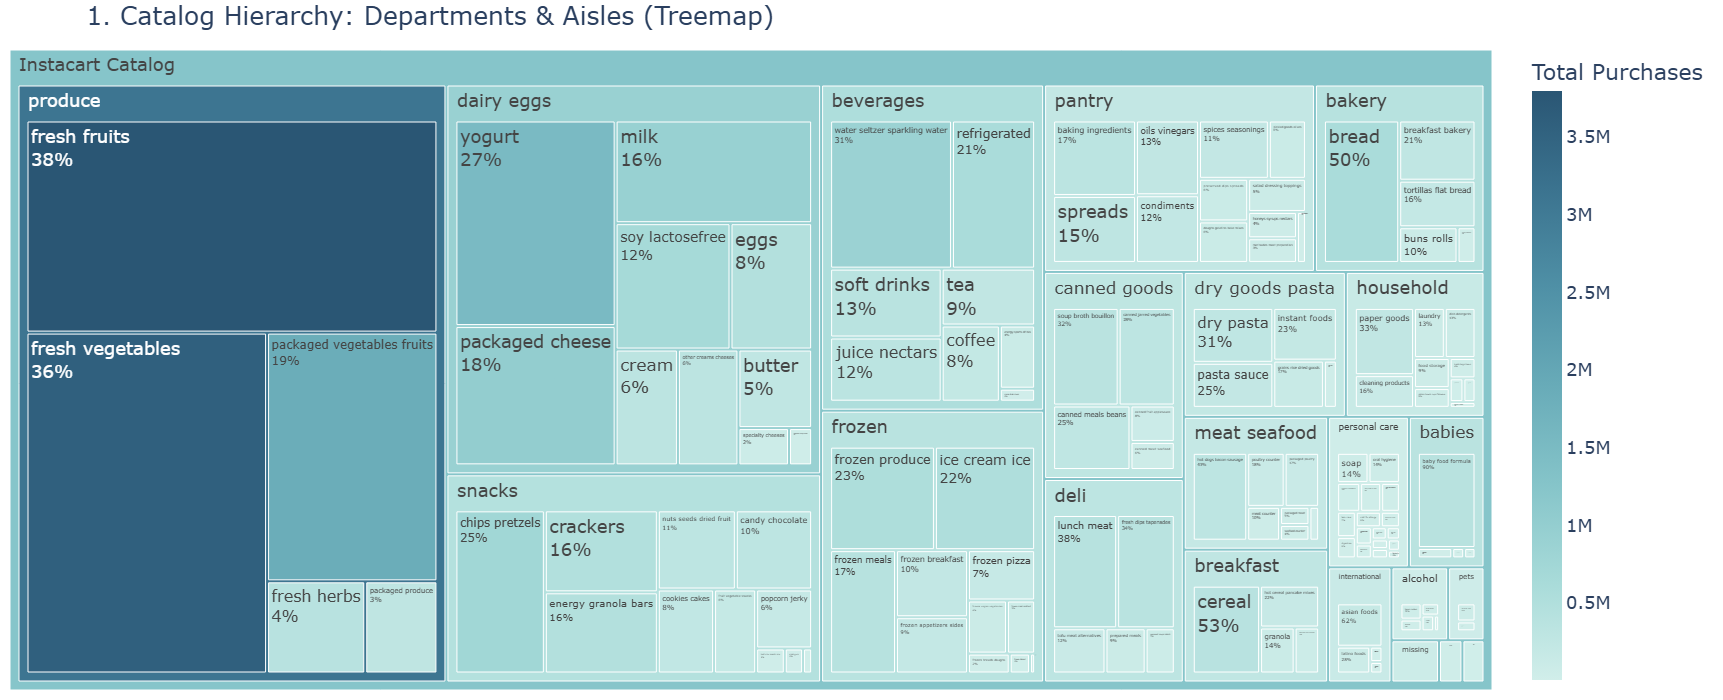

In [4]:

print("Loading Instacart Data...")
df = load_instacart_data()

print("1. Generating Treemap...")
fig1 = plot_department_aisle_treemap(df)
fig1.show()


2. Generating Temporal Heatmap...


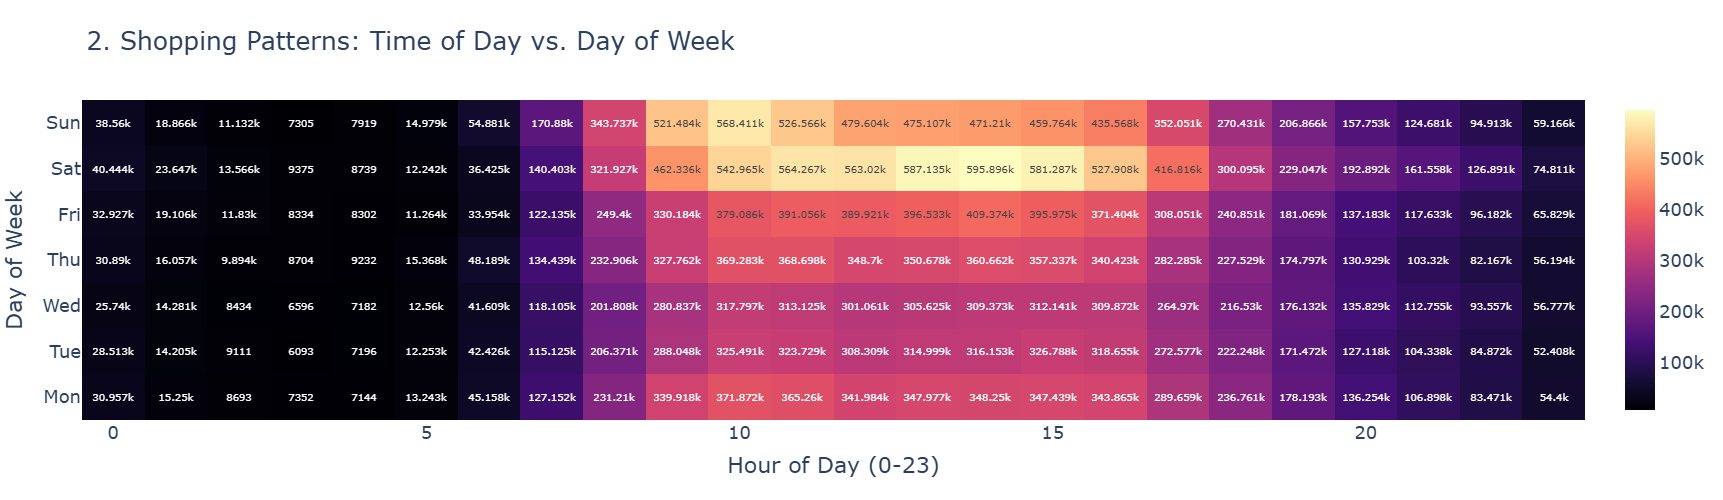

In [5]:

print("2. Generating Temporal Heatmap...")
fig2 = plot_temporal_shopping_heatmap(df)
fig2.show()


3. Generating Top Products...


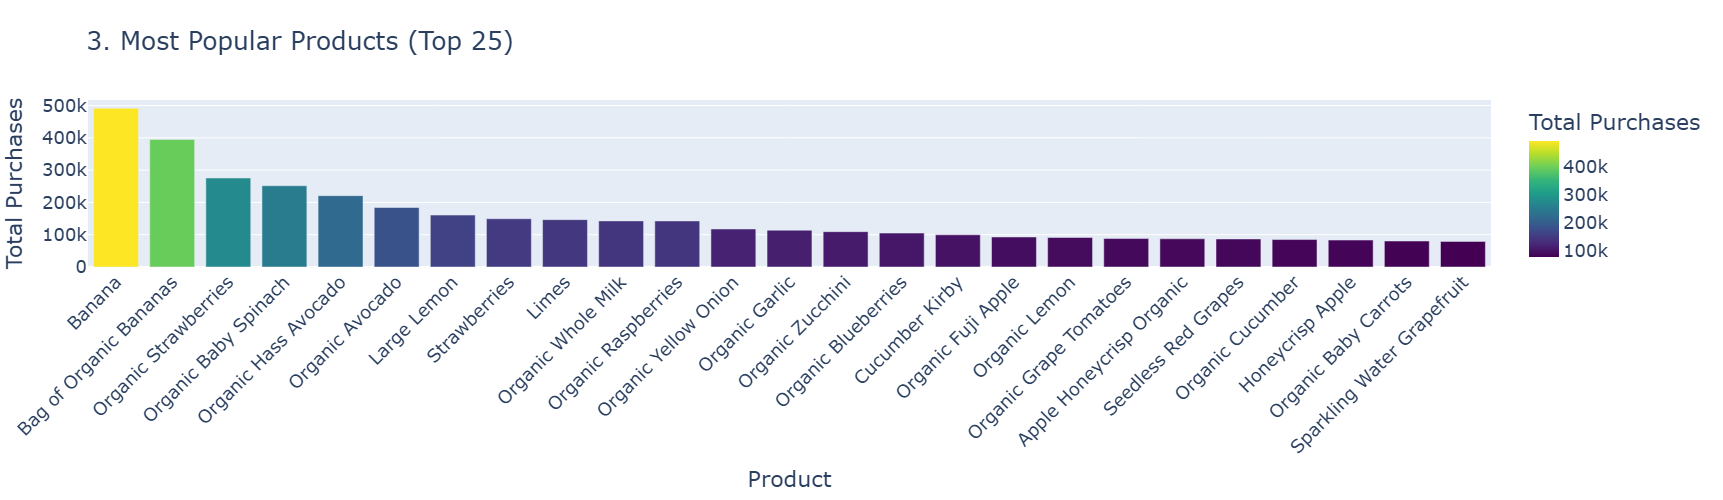

In [6]:

print("3. Generating Top Products...")
fig3 = plot_top_products(df)
fig3.show()


4. Generating Reorder Probability...


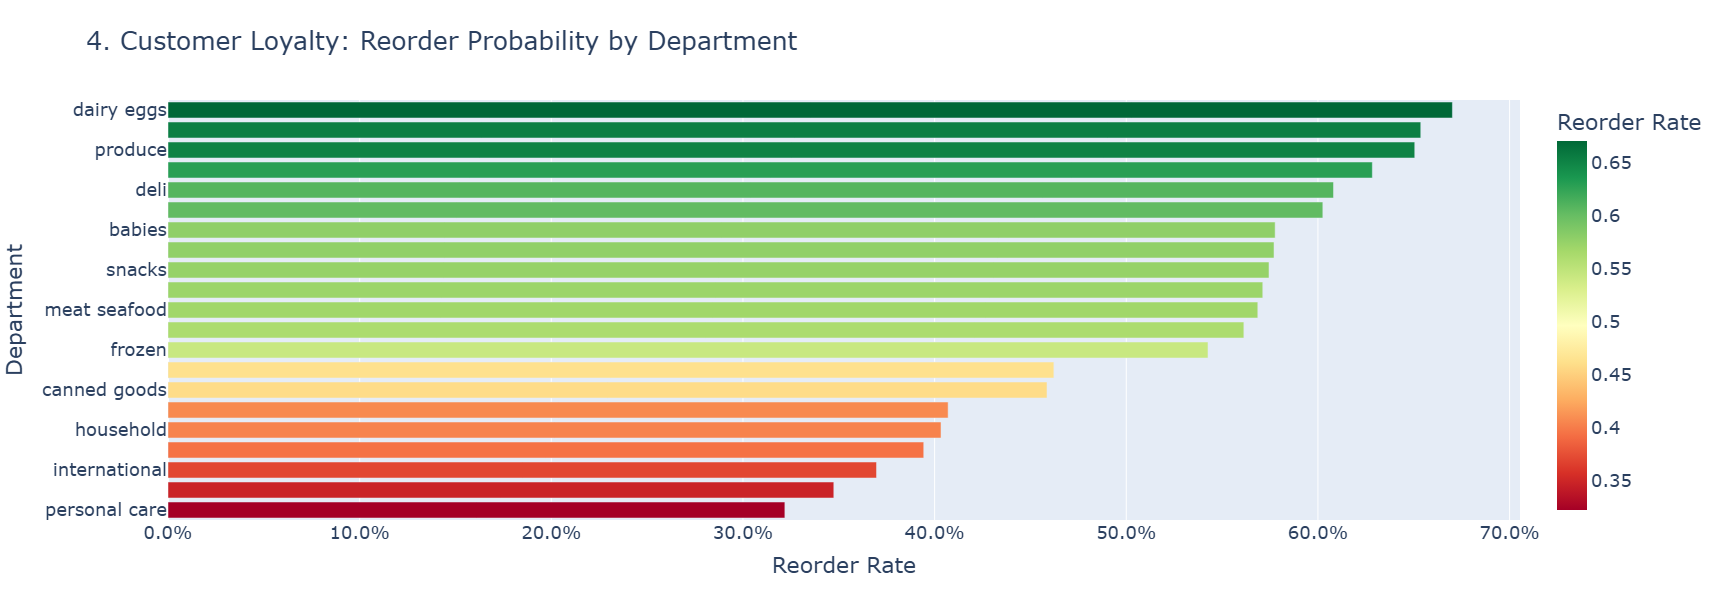

In [7]:

print("4. Generating Reorder Probability...")
fig4 = plot_reorder_probability(df)
fig4.show()


5. Generating Cart Position Anchors...


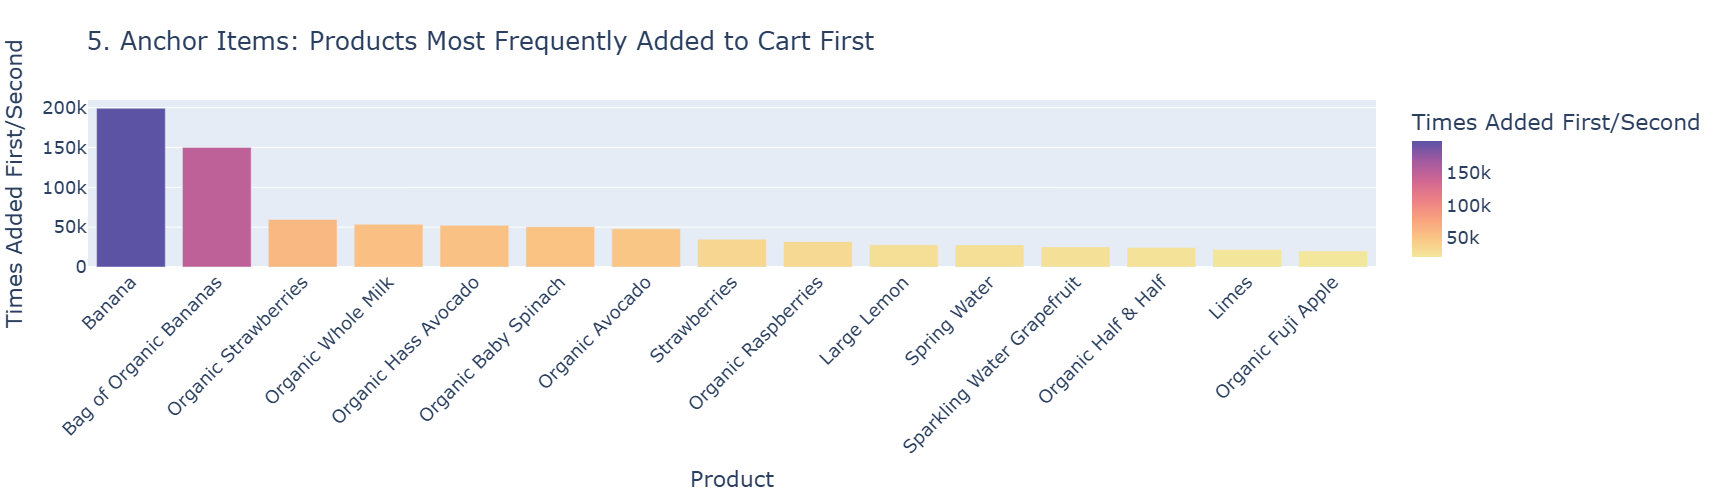

6. Generating Market Basket...


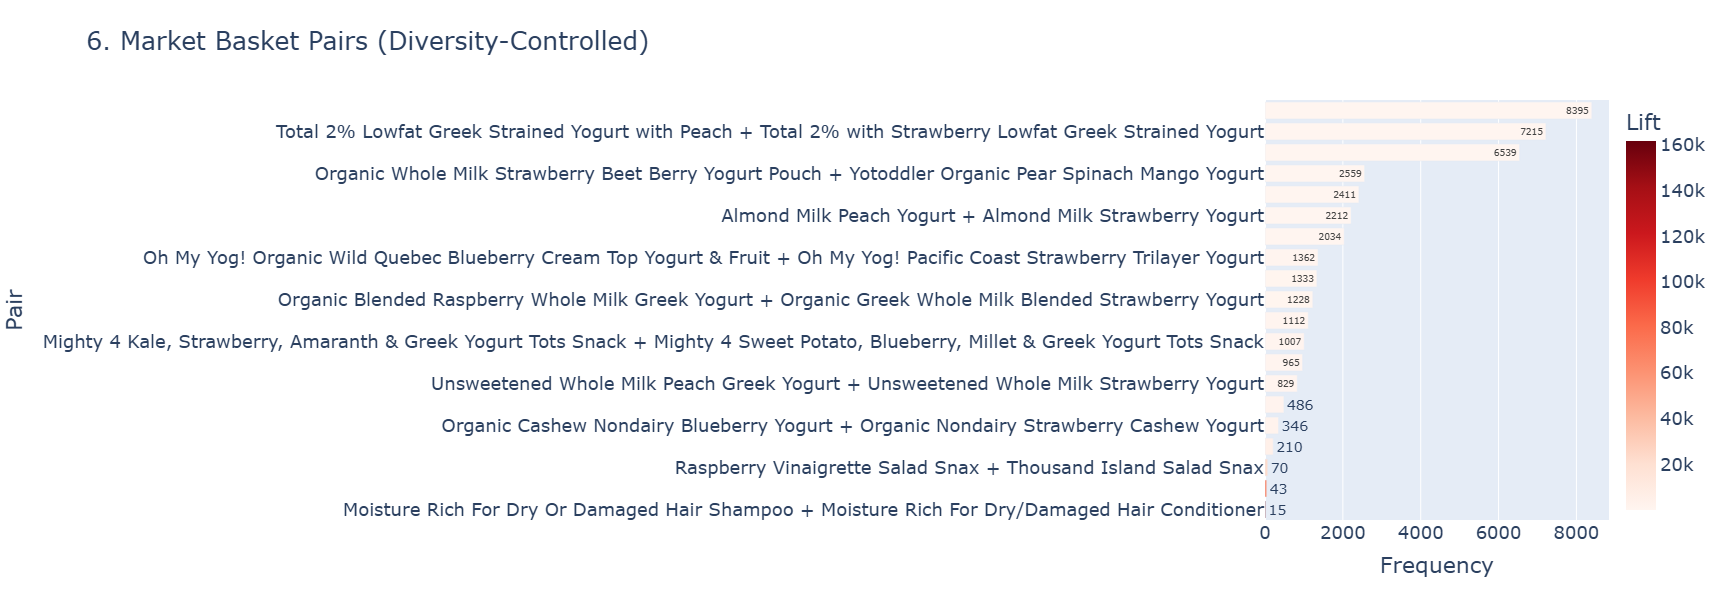

In [8]:

print("5. Generating Cart Position Anchors...")
fig5 = plot_cart_position_anchors(df)
fig5.show()

print("6. Generating Market Basket...")
fig6 = plot_market_basket(df)
fig6.show()
